<a href="https://colab.research.google.com/github/MigXDev/CS_Datos_I_DESAFIO_2/blob/main/FlightOnTime_I_ETL_Miguel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plantilla ETL** - Predicción de Retrasos de Vuelos (**FlightOnTime**)

Este notebook ETL está diseñado para procesar y preparar datos históricos de vuelos para el proyecto FlightOnTime, una solución predictiva que estima si un vuelo despegará a tiempo o con retraso.

**Objetivo:** Transformar datos crudos de vuelos en un dataset limpio y estructurado, listo para entrenar modelos de clasificación binaria (Puntual vs Retrasado).

**Tipo de datos:** Dataset de aviación civil con información operacional de vuelos comerciales, incluyendo aerolíneas, aeropuertos, horarios, distancias y estado de puntualidad.

## 1. Configuración del colab

In [ ]:
# Importación de librerías

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', 100)      # Limitar filas mostradas
pd.set_option('display.float_format', '{:.2f}'.format)  # Formato decimal

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Entorno configurado correctamente")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de numpy: {np.__version__}")

Entorno configurado correctamente
Versión de pandas: 2.2.2
Versión de numpy: 2.0.2


## 2. Extracion y validacion de datos

In [ ]:
# Cargar desde URL
url = '/content/2009.csv'
df = pd.read_csv(url)

print("Datos cargados exitosamente ()")

Datos cargados exitosamente ()


In [ ]:
print("=" * 80)
print("VERIFICACIÓN INICIAL DE DATOS")
print("=" * 80)

# Primeras filas: vista rapida de la estructura
print("\n1. PRIMERAS 5 FILAS:")
df.head()

VERIFICACIÓN INICIAL DE DATOS

1. PRIMERAS 5 FILAS:


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2009-01-01,XE,1204,DCA,EWR,1100,1058.00,-2.00,18.00,1116.00,1158.00,8.00,1202.00,1206.00,4.00,0.00,NaN,0.00,62.00,68.00,42.00,199.00,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-01,XE,1206,EWR,IAD,1510,1509.00,-1.00,28.00,1537.00,1620.00,4.00,1632.00,1624.00,-8.00,0.00,NaN,0.00,82.00,75.00,43.00,213.00,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-01,XE,1207,EWR,DCA,1100,1059.00,-1.00,20.00,1119.00,1155.00,6.00,1210.00,1201.00,-9.00,0.00,NaN,0.00,70.00,62.00,36.00,199.00,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-01,XE,1208,DCA,EWR,1240,1249.00,9.00,10.00,1259.00,1336.00,9.00,1357.00,1345.00,-12.00,0.00,NaN,0.00,77.00,56.00,37.00,199.00,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-01,XE,1209,IAD,EWR,1715,1705.00,-10.00,24.00,1729.00,1809.00,13.00,1900.00,1822.00,-38.00,0.00,NaN,0.00,105.00,77.00,40.00,213.00,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Informacion general: tipos de datos, valores nulos, memoria
print("\n2. INFORMACIÓN GENERAL:")
print(df.info())

# Dimensiones: cantidad de filas y columnas
print("\n3. DIMENSIONES DEL DATASET:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Estadísticas descriptivas: medidas de tendencia central y dispersion
print("\n4. ESTADÍSTICAS DESCRIPTIVAS:")
df.describe()


2. INFORMACIÓN GENERAL:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67329 entries, 0 to 67328
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FL_DATE              67329 non-null  object 
 1   OP_CARRIER           67329 non-null  object 
 2   OP_CARRIER_FL_NUM    67329 non-null  int64  
 3   ORIGIN               67329 non-null  object 
 4   DEST                 67329 non-null  object 
 5   CRS_DEP_TIME         67329 non-null  int64  
 6   DEP_TIME             66522 non-null  float64
 7   DEP_DELAY            66522 non-null  float64
 8   TAXI_OUT             66486 non-null  float64
 9   WHEELS_OFF           66486 non-null  float64
 10  WHEELS_ON            66385 non-null  float64
 11  TAXI_IN              66385 non-null  float64
 12  CRS_ARR_TIME         67328 non-null  float64
 13  ARR_TIME             66385 non-null  float64
 14  ARR_DELAY            66254 non-null  float64
 15  CANCELLED  

,OP_CARRIER_FL_NUM,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
count,67329.00,67329.00,66522.00,66522.00,66486.00,66486.00,66385.00,66385.00,67328.00,66385.00,66254.00,67328.00,67328.00,67328.00,66254.00,66254.00,67328.00,17088.00,17088.00,17088.00,17088.00,17088.00,0.00
mean,2291.72,1335.37,1349.51,12.59,16.32,1372.55,1493.48,7.17,1511.56,1499.18,9.69,0.01,0.00,132.10,129.67,106.20,740.01,16.19,2.80,13.40,0.12,21.83,NaN
std,2020.10,456.91,469.46,36.01,10.64,471.90,495.50,5.27,474.72,499.36,38.98,0.11,0.05,70.51,70.62,68.38,563.42,40.31,19.07,23.66,1.78,37.92,NaN
min,1.00,5.00,1.00,-32.00,1.00,1.00,1.00,1.00,1.00,1.00,-62.00,0.00,0.00,19.00,20.00,11.00,31.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,647.00,942.00,950.00,-4.00,10.00,1003.00,1123.00,4.00,1134.00,1127.00,-10.00,0.00,0.00,80.00,78.00,57.00,334.00,0.00,0.00,0.00,0.00,0.00,NaN
50%,1626.00,1326.00,1337.00,0.00,14.00,1351.00,1522.00,6.00,1526.00,1526.00,-1.00,0.00,0.00,115.00,113.00,89.00,590.00,2.00,0.00,4.00,0.00,2.00,NaN
75%,3412.00,1715.00,1731.00,14.00,19.00,1745.00,1907.00,8.00,1910.00,1913.00,15.00,0.00,0.00,163.00,161.00,136.00,972.00,17.00,0.00,18.00,0.00,29.00,NaN
max,7829.00,2359.00,2400.00,1178.00,218.00,2400.00,2400.00,145.00,2359.00,2400.00,1180.00,1.00,1.00,660.00,700.00,649.00,4962.00,1177.00,913.00,554.00,70.00,622.00,NaN


In [ ]:
# Tipos de datos por columna
print("\n5. TIPOS DE DATOS:")
print(df.dtypes)


5. TIPOS DE DATOS:
FL_DATE                 object
OP_CARRIER              object
OP_CARRIER_FL_NUM        int64
ORIGIN                  object
DEST                    object
CRS_DEP_TIME             int64
DEP_TIME               float64
DEP_DELAY              float64
TAXI_OUT               float64
WHEELS_OFF             float64
WHEELS_ON              float64
TAXI_IN                float64
CRS_ARR_TIME           float64
ARR_TIME               float64
ARR_DELAY              float64
CANCELLED              float64
CANCELLATION_CODE       object
DIVERTED               float64
CRS_ELAPSED_TIME       float64
ACTUAL_ELAPSED_TIME    float64
AIR_TIME               float64
DISTANCE               float64
CARRIER_DELAY          float64
WEATHER_DELAY          float64
NAS_DELAY              float64
SECURITY_DELAY         float64
LATE_AIRCRAFT_DELAY    float64
Unnamed: 27            float64
dtype: object


In [ ]:
print("=" * 80)
print("ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 80)

# Conteo de valores nulos por columna
print("\n1. VALORES NULOS:")
# Contar cantidad de valores nulos en cada columna
# Calcular porcentaje de valores nulos respecto al total de filas
# Crear DataFrame resumen con información de nulos
cant_nulo = df.isnull().sum()
porc_nulo = (cant_nulo / len(df)) * 100
dicc_nulo = pd.DataFrame({
    'Columna': cant_nulo.index,
    'Nulos': cant_nulo.values,
    'Porcentaje': porc_nulo.values
})
# Mostrar solo columnas con al menos un valor nulo
print(dicc_nulo[dicc_nulo['Nulos'] > 0])

# Conteo de valores atipicos
print("\n2. VALORES ATIPICOS:")
for col in df.columns:
    únicos = df[col].nunique(dropna=False)
    print(f"Columna '{col}': {únicos} valores únicos")
    if únicos <= 50:    # Imprima los valores si no hay muchos
        print(df[col].unique())
        print('-' * 40) # Linea divisora para una mejor visualizacion

# Conteo de duplicados
print(f"\n3. FILAS DUPLICADAS: {df.duplicated().sum()}")

# df.iloc["Num de fila NaN"]

ANÁLISIS DE CALIDAD DE DATOS

1. VALORES NULOS:
                Columna  Nulos  Porcentaje
6              DEP_TIME    807        1.20
7             DEP_DELAY    807        1.20
8              TAXI_OUT    843        1.25
9            WHEELS_OFF    843        1.25
10            WHEELS_ON    944        1.40
11              TAXI_IN    944        1.40
12         CRS_ARR_TIME      1        0.00
13             ARR_TIME    944        1.40
14            ARR_DELAY   1075        1.60
15            CANCELLED      1        0.00
16    CANCELLATION_CODE  66457       98.70
17             DIVERTED      1        0.00
18     CRS_ELAPSED_TIME      1        0.00
19  ACTUAL_ELAPSED_TIME   1075        1.60
20             AIR_TIME   1075        1.60
21             DISTANCE      1        0.00
22        CARRIER_DELAY  50241       74.62
23        WEATHER_DELAY  50241       74.62
24            NAS_DELAY  50241       74.62
25       SECURITY_DELAY  50241       74.62
26  LATE_AIRCRAFT_DELAY  50241       74.62
27    

In [ ]:
for col in df.columns:
        nulo = df[col].isna().sum()  # Cuenta los valores nulos
        #Si el numero de valores nulo es mayor a 0, muestra ejemplos de los datos nulo
        if nulo > 0:
            print(f"Las Filas con datos nulos en '{col}' son: ")
            # Mostrar el índice de las filas con nulos, o la fila completa si se desea
            print(df[df[col].isna()][col].sample(min(2, nulo)))
            print('-' * 50)

Las Filas con datos nulos en 'DEP_TIME' son: 
43276   NaN
57033   NaN
Name: DEP_TIME, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'DEP_DELAY' son: 
13364   NaN
3721    NaN
Name: DEP_DELAY, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'TAXI_OUT' son: 
53956   NaN
27994   NaN
Name: TAXI_OUT, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'WHEELS_OFF' son: 
20733   NaN
43694   NaN
Name: WHEELS_OFF, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'WHEELS_ON' son: 
50989   NaN
3546    NaN
Name: WHEELS_ON, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'TAXI_IN' son: 
21885   NaN
30250   NaN
Name: TAXI_IN, dtype: float64
--------------------------------------------------
Las Filas con datos nulos en 'CRS_ARR_TIME' son: 
67328   NaN
Name: CRS_ARR_TIME, 

In [ ]:
# Analisis de dato individual
"""
En el mismo dato vemos que la mayoria de variables,
se encuentran en estado NaN debido a que el vuelo se cancelo.
"CANCELLED == 1"
"""
print(df.iloc[5093])

FL_DATE                2009-01-01
OP_CARRIER                     US
OP_CARRIER_FL_NUM             660
ORIGIN                        PHX
DEST                          SNA
CRS_DEP_TIME                 1746
DEP_TIME                      NaN
DEP_DELAY                     NaN
TAXI_OUT                      NaN
WHEELS_OFF                    NaN
WHEELS_ON                     NaN
TAXI_IN                       NaN
CRS_ARR_TIME              1803.00
ARR_TIME                      NaN
ARR_DELAY                     NaN
CANCELLED                    1.00
CANCELLATION_CODE               A
DIVERTED                     0.00
CRS_ELAPSED_TIME            77.00
ACTUAL_ELAPSED_TIME           NaN
AIR_TIME                      NaN
DISTANCE                   338.00
CARRIER_DELAY                 NaN
WEATHER_DELAY                 NaN
NAS_DELAY                     NaN
SECURITY_DELAY                NaN
LATE_AIRCRAFT_DELAY           NaN
Unnamed: 27                   NaN
Name: 5093, dtype: object


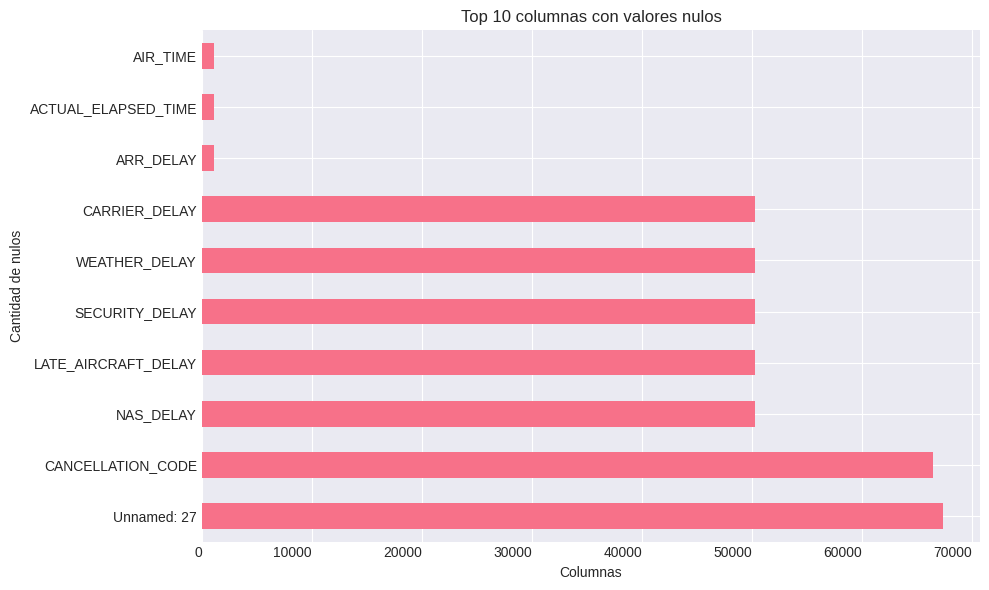

In [ ]:
# Visualización de valores nulos
# Solo crear gráfico si existen valores nulos en el dataset
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10, 6))
    cant_nulo.sort_values(ascending=False).head(10).plot(kind='barh')
    plt.title('Top 10 columnas con valores nulos')
    plt.xlabel('Columnas')
    plt.ylabel('Cantidad de nulos')
    plt.xticks(ha='right')
    plt.tight_layout()
    plt.show()

## 3. Limpieza y transformación de datos

In [ ]:
# Crear una copia para preservar los datos originales
# Esto permite volver atrás si algo sale mal
df_limpio = df.copy()

print("Copia de trabajo creada")
print(f"Dimensiones iniciales: {df_limpio.shape}")

df_limpio.sample(5)

Copia de trabajo creada
Dimensiones iniciales: (67329, 28)


,FL_DATE,OP_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
27966,2009-01-02,UA,410,SMF,DEN,600,554.00,-6.00,11.00,605.00,852.00,5.00,928.00,857.00,-31.00,0.00,NaN,0.00,148.00,123.00,107.00,909.00,NaN,NaN,NaN,NaN,NaN,NaN
22344,2009-01-02,EV,5649,DSM,ATL,1601,1617.00,16.00,8.00,1625.00,1906.00,9.00,1911.00,1915.00,4.00,0.00,NaN,0.00,130.00,118.00,101.00,743.00,NaN,NaN,NaN,NaN,NaN,NaN
57012,2009-01-04,EV,5334,ABY,ATL,1120,1142.00,22.00,10.00,1152.00,1235.00,15.00,1215.00,1250.00,35.00,0.00,NaN,0.00,55.00,68.00,43.00,146.00,13.00,0.00,19.00,0.00,3.00,NaN
19173,2009-01-02,B6,1085,JFK,CLT,1710,1706.00,-4.00,30.00,1736.00,1903.00,7.00,1937.00,1910.00,-27.00,0.00,NaN,0.00,147.00,124.00,87.00,541.00,NaN,NaN,NaN,NaN,NaN,NaN
4248,2009-01-01,US,959,CLT,FLL,2210,2233.00,23.00,18.00,2251.00,20.00,3.00,2359.00,23.00,24.00,0.00,NaN,0.00,109.00,110.00,89.00,631.00,23.00,0.00,1.00,0.00,0.00,NaN


In [ ]:
# MANEJO DE VALORES NULOS
print("=" * 80)
print("MANEJO DE VALORES NULOS")
print("=" * 80)

# Rellenar todos los valores nulos con 0
# NOTA: Esta es una estrategia general; considerar estrategias específicas por columna
df_limpio.fillna(0, inplace=True)

# La columna `Unnamed: 27` tiene un `100%` de valores NAN,
# por lo tanto se considera no necesaria para el modelado predictivo
df_limpio = df_limpio.drop(columns=["Unnamed: 27"])

MANEJO DE VALORES NULOS


In [ ]:
# CONVERSIÓN DE TIPOS DE DATOS
print("=" * 80)
print("CONVERSIÓN DE TIPOS DE DATOS")
print("=" * 80)

# Mostrar información de memoria antes de la conversión
df_limpio.info(memory_usage='deep')

CONVERSIÓN DE TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67329 entries, 0 to 67328
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FL_DATE              67329 non-null  object 
 1   OP_CARRIER           67329 non-null  object 
 2   OP_CARRIER_FL_NUM    67329 non-null  int64  
 3   ORIGIN               67329 non-null  object 
 4   DEST                 67329 non-null  object 
 5   CRS_DEP_TIME         67329 non-null  int64  
 6   DEP_TIME             67329 non-null  float64
 7   DEP_DELAY            67329 non-null  float64
 8   TAXI_OUT             67329 non-null  float64
 9   WHEELS_OFF           67329 non-null  float64
 10  WHEELS_ON            67329 non-null  float64
 11  TAXI_IN              67329 non-null  float64
 12  CRS_ARR_TIME         67329 non-null  float64
 13  ARR_TIME             67329 non-null  float64
 14  ARR_DELAY            67329 non-null  float64
 15  CANCELL

In [ ]:
# Variable fecha: convertir a tipo datetime para facilitar manipulación temporal
df_limpio['FL_DATE'] = pd.to_datetime(df_limpio['FL_DATE'], errors='coerce')

# Variables binarias: convertir a tipo booleano para optimizar memoria
bin_cols = ['CANCELLED', 'DIVERTED']

for cols in bin_cols:
    df_limpio[cols] = df_limpio[cols].astype('bool')

# Variables categóricas: convertir a tipo "category" para optimizar memoria
# y mejorar rendimiento en operaciones de agrupación
cat_cols = [
    'OP_CARRIER', 'ORIGIN', 'DEST', 'CANCELLATION_CODE'
]
for cols in cat_cols:
    df_limpio[cols] = df_limpio[cols].astype('category')

# Cambio de tipo de dato float64 --> float32
# Esto reduce el uso de memoria a la mitad con pérdida mínima de precisión
float_cols = [
    'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT',
    'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME',
    'ARR_TIME', 'ARR_DELAY', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME',
    'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY',
    'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY'
]

for col in float_cols:
    df_limpio[col] = df_limpio[col].astype('float32')

print("\nTipos de datos actualizados correctamente *tilde*")
# Mostrar información de memoria después de la conversión
df_limpio.info(memory_usage='deep')


Tipos de datos actualizados correctamente *tilde*
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67329 entries, 0 to 67328
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   FL_DATE              67329 non-null  datetime64[ns]
 1   OP_CARRIER           67329 non-null  category      
 2   OP_CARRIER_FL_NUM    67329 non-null  int64         
 3   ORIGIN               67329 non-null  category      
 4   DEST                 67329 non-null  category      
 5   CRS_DEP_TIME         67329 non-null  float32       
 6   DEP_TIME             67329 non-null  float32       
 7   DEP_DELAY            67329 non-null  float32       
 8   TAXI_OUT             67329 non-null  float32       
 9   WHEELS_OFF           67329 non-null  float32       
 10  WHEELS_ON            67329 non-null  float32       
 11  TAXI_IN              67329 non-null  float32       
 12  CRS_ARR_TIME         67329 non-null  

In [ ]:
# RENOMBRADO DE COLUMNAS
print("=" * 80)
print("RENOMBRADO DE COLUMNAS")
print("=" * 80)

# Diccionario de mapeo: en español
cols_renom = {
    'FL_DATE': 'VUEL_FECHA',
    'OP_CARRIER': 'OP_AEROLINEA',
    'OP_CARRIER_FL_NUM': 'OP_NUM_VUEL',
    'ORIGIN': 'ORIGEN',
    'DEST': 'DESTINO',
    'CRS_DEP_TIME': 'H_SALIDA_PROG',
    'DEP_TIME': 'H_SALIDA_RE',
    'DEP_DELAY': 'RET_SALIDA',
    'TAXI_OUT': 'TAXI_SALIDA',
    'WHEELS_OFF': 'DESPEGUE',
    'WHEELS_ON': 'ATERRIZAJE',
    'TAXI_IN': 'TAXI_ENTRADA',
    'CRS_ARR_TIME': 'H_LLEG_PROG',
    'ARR_TIME': 'H_LLEG_RE',
    'ARR_DELAY': 'RET_LLEGADA',
    'CANCELLED': 'CANCELADO',
    'CANCELLATION_CODE': 'COD_CANC',
    'DIVERTED': 'DESVIADO',
    'CRS_ELAPSED_TIME': 'T_ESTIMADO',
    'ACTUAL_ELAPSED_TIME': 'T_REAL',
    'AIR_TIME': 'T_VUELO',
    'DISTANCE': 'DISTANCIA',
    'CARRIER_DELAY': 'RET_AEROLINEA',
    'WEATHER_DELAY': 'RET_CLIMA',
    'NAS_DELAY': 'RET_NAS',
    'SECURITY_DELAY': 'RET_SEGURIDAD',
    'LATE_AIRCRAFT_DELAY': 'RET_AVION_TARDE'
}
"""
Convenciones de nomenclatura:
OP: Clave operativa de avión
H: Hora
RET: Retraso (Delay)
PROG: Programado (CRS)
RE: Real (Actual)
T: Tiempo / Duración
NAS: Se mantiene igual por ser el estándar técnico del Sistema Aéreo Nacional
"""

# Aplicar el renombrado de columnas
df_limpio = df_limpio.rename(columns=cols_renom)

# Estandarizar nombres: minúsculas, sin espacios, sin caracteres especiales
df_limpio.columns = df_limpio.columns.str.lower()  # A minúsculas
df_limpio.columns = df_limpio.columns.str.replace(' ', '_')  # Espacios a guiones bajos
df_limpio.columns = df_limpio.columns.str.replace('[^a-zA-Z0-9_]', '', regex=True)  # Quitar especiales

print("Columnas renombradas:")
print(list(df_limpio.columns))

RENOMBRADO DE COLUMNAS
Columnas renombradas:
['vuel_fecha', 'op_aerolinea', 'op_num_vuel', 'origen', 'destino', 'h_salida_prog', 'h_salida_re', 'ret_salida', 'taxi_salida', 'despegue', 'aterrizaje', 'taxi_entrada', 'h_lleg_prog', 'h_lleg_re', 'ret_llegada', 'cancelado', 'cod_canc', 'desviado', 't_estimado', 't_real', 't_vuelo', 'distancia', 'ret_aerolinea', 'ret_clima', 'ret_nas', 'ret_seguridad', 'ret_avion_tarde']


In [ ]:
df_limpio.sample(5)

,vuel_fecha,op_aerolinea,op_num_vuel,origen,destino,h_salida_prog,h_salida_re,ret_salida,taxi_salida,despegue,aterrizaje,taxi_entrada,h_lleg_prog,h_lleg_re,ret_llegada,cancelado,cod_canc,desviado,t_estimado,t_real,t_vuelo,distancia,ret_aerolinea,ret_clima,ret_nas,ret_seguridad,ret_avion_tarde
65846,2009-01-04,OO,4872,SMF,SLC,1620.00,1644.00,24.00,8.00,1652.00,1915.00,8.00,1855.00,1923.00,28.00,False,0,False,95.00,99.00,83.00,532.00,0.00,0.00,4.00,0.00,24.00
49169,2009-01-03,B6,791,BOS,SJU,2105.00,2055.00,-10.00,21.00,2116.00,137.00,5.00,156.00,142.00,-14.00,False,0,False,231.00,227.00,201.00,1674.00,0.00,0.00,0.00,0.00,0.00
576,2009-01-01,XE,2840,EWR,MHT,2130.00,2124.00,-6.00,29.00,2153.00,2232.00,7.00,2252.00,2239.00,-13.00,False,0,False,82.00,75.00,39.00,209.00,0.00,0.00,0.00,0.00,0.00
28946,2009-01-02,US,1017,CLT,PBI,1620.00,1615.00,-5.00,15.00,1630.00,1755.00,5.00,1807.00,1800.00,-7.00,False,0,False,107.00,105.00,85.00,590.00,0.00,0.00,0.00,0.00,0.00
31692,2009-01-02,WN,1810,MDW,IAD,1650.00,1654.00,4.00,7.00,1701.00,1910.00,6.00,1930.00,1916.00,-14.00,False,0,False,100.00,82.00,69.00,577.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
print(df_limpio.loc[65846])

vuel_fecha         2009-01-04 00:00:00
op_aerolinea                        OO
op_num_vuel                       4872
origen                             SMF
destino                            SLC
h_salida_prog                  1620.00
h_salida_re                    1644.00
ret_salida                       24.00
taxi_salida                       8.00
despegue                       1652.00
aterrizaje                     1915.00
taxi_entrada                      8.00
h_lleg_prog                    1855.00
h_lleg_re                      1923.00
ret_llegada                      28.00
cancelado                        False
cod_canc                             0
desviado                         False
t_estimado                       95.00
t_real                           99.00
t_vuelo                          83.00
distancia                       532.00
ret_aerolinea                     0.00
ret_clima                         0.00
ret_nas                           4.00
ret_seguridad            